This notebook estimates optical aberrations in the GSpec setup according to the coupling achieved into the single mode fiber with the single aperture setup.

# IMPORTS

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

# PUPIL PLANE

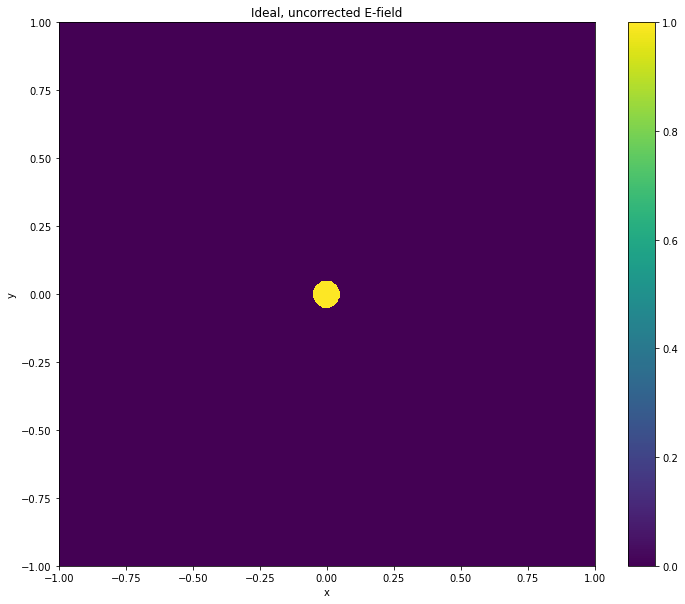

In [6]:
# Define spatial sampling
samples = 1000
pupil_ratio = 0.05
x_samples = np.linspace(-1, 1, samples+1) * u.cm
y_samples = np.copy(x_samples)
x, y = np.meshgrid(x_samples, x_samples) # Spatial grid

# Define ideal, uncorrected electric field
A = np.zeros((samples+1, samples+1)) 
A[(x**2 + y**2) < pupil_ratio**2 * u.cm**2] = 1 # Circular aperture

# Define amplitude/phase contributions from aberrations and DM
A_aber = lambda alpha, beta: np.exp(alpha + 1j*beta) # Aberrations
A_DM = lambda phi: np.exp(1j * phi) # DM

# Define electric field transformation from object to image plane
def C(U, x_samples, y_samples, return_freq=False):
    ''' Transforms electric field from object to image plane
        Inputs:
        - U: numpy 2D array of electric field in object plane
        - x_samples, y_samples: numpy 1D arrays of x/y-values being sampled
        - return_freq: returns FFT frequencies when True
        Outputs:
        - I: numpy 2D array of electric field in image planet
        - X, Y: numpy 2D arrays of x/y frequencies being sampled; only returned when return_freq=True
    '''
    dx, dy = np.diff(x_samples)[0], np.diff(y_samples)[0]
    X = np.fft.fftshift(np.fft.fftfreq(len(x_samples), d=dx))
    Y = np.fft.fftshift(np.fft.fftfreq(len(y_samples), d=dx))
    I = np.fft.fft2(np.fft.ifftshift(U)) # shift zero frequency component to center of spectrum
    I = np.fft.fftshift(I) # shift back
    if return_freq:
        return I, X, Y
    else:
        return I
    
# Show ideal, uncorrected aperture
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(A)), np.max(np.absolute(A))]
im = ax.pcolormesh(x.value, y.value, np.absolute(A), vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Ideal, uncorrected E-field')
fig.colorbar(im, ax=ax)
plt.show()